In [5]:
# Install required packages
!pip install imageio
!pip install git+https://github.com/tensorflow/docs
!pip install tensorflow-datasets

  Cloning https://github.com/tensorflow/docs to /tmp/pip-req-build-lugft9q2
  Running command git clone --filter=blob:none --quiet https://github.com/tensorflow/docs /tmp/pip-req-build-lugft9q2
  Resolved https://github.com/tensorflow/docs to commit 7c3650212740204359d4ceae481abc79345541be
  Preparing metadata (setup.py) ... done
  Created wheel for tensorflow-docs: filename=tensorflow_docs-2026.1.14.40212-py3-none-any.whl size=186922 sha256=398ff0762b9d557b7424519bd6a1d40e75c1c1bcb08cb40d03ed696ffe63ec6e
  Stored in directory: /tmp/pip-ephem-wheel-cache-icl_nf1c/wheels/3e/88/34/48d2789bc9d37b33ddce06bccc454fae0285e5396d0a5be9d9
Successfully built tensorflow-docs


In [6]:
import tensorflow as tf
print(tf.__version__)

2.19.0


In [7]:
import glob
import imageio
import matplotlib.pyplot as plt
import numpy as np
import os
import PIL
from tensorflow.keras import layers
import time
import tensorflow_datasets as tfds
from IPython import display

In [22]:


dataset, info = tfds.load('svhn_cropped', split='train', with_info=True, as_supervised=False)
print(info)

tfds.core.DatasetInfo(
    name='svhn_cropped',
    full_name='svhn_cropped/3.1.0',
    description="""
    The Street View House Numbers (SVHN) Dataset is an image digit recognition
    dataset of over 600,000 digit images coming from real world data. Images are
    cropped to 32x32.
    """,
    homepage='http://ufldl.stanford.edu/housenumbers/',
    data_dir='/root/tensorflow_datasets/svhn_cropped/3.1.0',
    file_format=tfrecord,
    download_size=1.47 GiB,
    dataset_size=1.09 GiB,
    features=FeaturesDict({
        'id': Text(shape=(), dtype=string),
        'image': Image(shape=(32, 32, 3), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=10),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'extra': <SplitInfo num_examples=531131, num_shards=8>,
        'test': <SplitInfo num_examples=26032, num_shards=1>,
        'train': <SplitInfo num_examples=73257, num_shards=1>

In [23]:

BUFFER_SIZE = 60000
BATCH_SIZE  = 512
AUTOTUNE    = tf.data.AUTOTUNE

dataset, info = tfds.load('svhn_cropped', split='train', with_info=True, as_supervised=False)
print(info.features)

def preprocess(sample):
    image = tf.cast(sample['image'], tf.float32)
    image = (image - 127.5) / 127.5
    return image

train_dataset = (
    dataset
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .shuffle(BUFFER_SIZE)
    .batch(BATCH_SIZE, drop_remainder=True)
    .prefetch(AUTOTUNE)
)


for batch in train_dataset.take(1):
    print('Batch shape:', batch.shape)
    print('Pixel range:', batch.numpy().min(), 'to', batch.numpy().max())

FeaturesDict({
    'id': Text(shape=(), dtype=string),
    'image': Image(shape=(32, 32, 3), dtype=uint8),
    'label': ClassLabel(shape=(), dtype=int64, num_classes=10),
})
Batch shape: (512, 32, 32, 3)
Pixel range: -1.0 to 1.0


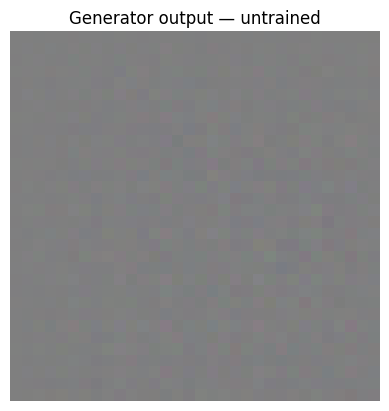

Generator output shape: (1, 32, 32, 3)


In [24]:


def make_generator_model():
    model = tf.keras.Sequential([
        layers.Input(shape=(100,)),
        layers.Dense(4 * 4 * 256, use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(0.2),

        layers.Reshape((4, 4, 256)),


        layers.Conv2DTranspose(128, (5, 5), strides=(2, 2), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(0.2),

        layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(0.2),


        layers.Conv2DTranspose(3, (5, 5), strides=(2, 2), padding='same',
                               use_bias=False, activation='tanh'),

    ], name='generator')
    return model

generator = make_generator_model()


noise = tf.random.normal([1, 100])
gen_img = generator(noise, training=False)
plt.imshow(gen_img[0] * 0.5 + 0.5)
plt.title('Generator output — untrained')
plt.axis('off')
plt.show()
print('Generator output shape:', gen_img.shape)

In [25]:


def make_discriminator_model():
    model = tf.keras.Sequential([
        layers.Input(shape=(32, 32, 3)),

        layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same'),
        layers.LeakyReLU(0.2),
        layers.Dropout(0.3),

        layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'),
        layers.LeakyReLU(0.2),
        layers.Dropout(0.3),

        layers.Conv2D(256, (5, 5), strides=(2, 2), padding='same'),
        layers.LeakyReLU(0.2),
        layers.Dropout(0.3),

        layers.Flatten(),
        layers.Dense(1),
    ], name='discriminator')
    return model

discriminator = make_discriminator_model()
discriminator.summary()

decision = discriminator(gen_img)
print('Discriminator decision on untrained image:', decision.numpy())

Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_9 (LeakyReLU)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_10 (LeakyReLU)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 256)      │       819,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_11 (LeakyReLU)      │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │         4,097 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,033,345 (3.94 MB)

 Trainable params: 1,033,345 (3.94 MB)

 Non-trainable params: 0 (0.00 B)

Discriminator decision on untrained image: [[-0.00078178]]


In [26]:

cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)


generator_optimizer     = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

In [13]:
checkpoint_dir    = './training_checkpoints'
checkpoint_prefix = os.path.join(checkpoint_dir, 'ckpt')
checkpoint = tf.train.Checkpoint(
    generator_optimizer=generator_optimizer,
    discriminator_optimizer=discriminator_optimizer,
    generator=generator,
    discriminator=discriminator
)

In [14]:
EPOCHS     = 50
noise_dim  = 100

num_examples_to_generate = 16
seed = tf.random.normal([num_examples_to_generate, noise_dim])

In [15]:

def generate_and_save_images(model, epoch, test_input):
    predictions = model(test_input, training=False)
    fig = plt.figure(figsize=(4, 4))
    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i + 1)
        img = np.clip(predictions[i].numpy() * 0.5 + 0.5, 0, 1)
        plt.imshow(img)
        plt.axis('off')
    plt.suptitle(f'Epoch {epoch}', fontsize=10)
    plt.tight_layout()
    plt.savefig(f'image_at_epoch_{epoch:04d}.png')
    plt.show()

In [16]:
@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, noise_dim])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss  = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator     = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

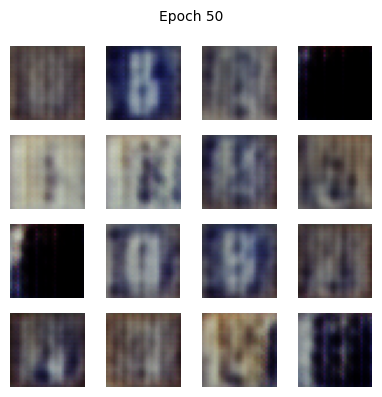

In [17]:
def train(dataset, epochs):
    for epoch in range(epochs):
        start = time.time()

        for image_batch in dataset:
            train_step(image_batch)

        display.clear_output(wait=True)
        generate_and_save_images(generator, epoch + 1, seed)

        if (epoch + 1) % 15 == 0:
            checkpoint.save(file_prefix=checkpoint_prefix)

        print('Time for epoch {} is {:.2f} sec'.format(epoch + 1, time.time() - start))

    display.clear_output(wait=True)
    generate_and_save_images(generator, epochs, seed)

train(train_dataset, EPOCHS)

In [18]:
checkpoint.restore(tf.train.latest_checkpoint(checkpoint_dir))

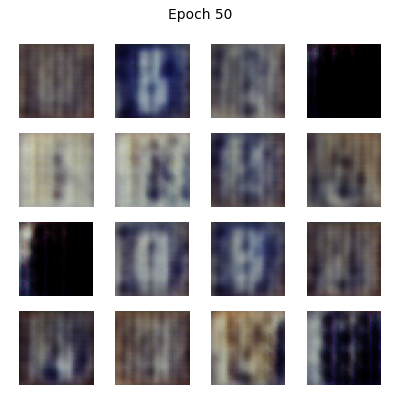

In [19]:
def display_image(epoch_no):
    return PIL.Image.open(f'image_at_epoch_{epoch_no:04d}.png')

display_image(EPOCHS)

In [20]:
anim_file = 'dcgan_svhn.gif'
with imageio.get_writer(anim_file, mode='I') as writer:
    filenames = sorted(glob.glob('image*.png'))
    for filename in filenames:
        writer.append_data(imageio.imread(filename))
    writer.append_data(imageio.imread(filenames[-1]))

/tmp/ipykernel_3950/1024036345.py:5: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  writer.append_data(imageio.imread(filename))
/tmp/ipykernel_3950/1024036345.py:6: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  writer.append_data(imageio.imread(filenames[-1]))



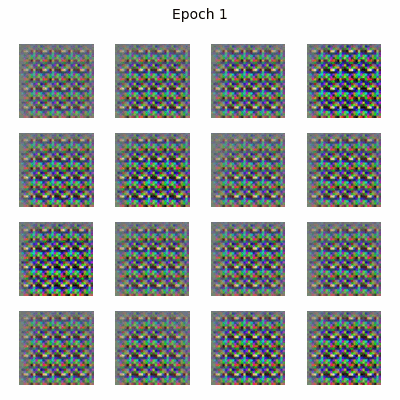

In [21]:
import tensorflow_docs.vis.embed as embed
embed.embed_file(anim_file)